# Fast Food Marketing Campaign A/B Test Dataset Analysis

### INTRODUCTION

In this analysis, I have taken the "Fast Food Marketing Campaign A/B Test" data published on Kaggle from the IBM Watson Analytics community. A fast-food chain is evaluating three marketing strategies to promote a new menu item. The item was launched in various markets in different locations, each using a different strategy, and weekly sales data were collected over four weeks.

The following notebook will be structured as follows: 
1. Goal
2. Hypothesis 
3. Target Metric 
4. Data Preparation
5. Calculations 
6. Decision

### 1. GOAL 

The goal of this A/B test is to determine which of three different marketing strategies (Promotions 1, 2 and 3) generates the highest weekly sales for a new menu item. 

### 2. HYPOTHESIS

Null Hypothesis (H₀): There is no significant difference in weekly sales between the three marketing promotions. 

Alternative Hypothesis (H₁): At least one promotion generates significantly different weekly sales compared to the others. 


### 3. TARGET METRIC

The target metric is the average weekly sales in thousands of dollars. This metric measures the effectiveness of each campaign in driving sales.

### 4. DATA PREPARATION

#### 4.1 Importing libraries and dataset

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

df = pd.read_csv('WA_Marketing-Campaign.csv')

print(df.dtypes)

df.head()

MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


#### 4.2 Checking Duplicates

In [81]:
df.isna().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [82]:
df.duplicated().sum()

np.int64(0)

There is neither missing data nor duplicates found. 

#### 4.3 Variant Proportions 

In [83]:
promotion_counts = df['Promotion'].value_counts()
total_samples = len(df)
promotion_proportions = {k: f"{(v / total_samples * 100):.0f}%" for k, v in promotion_counts.items()}

print("\nVariant proportions for each promotion:")
print(promotion_proportions)


Variant proportions for each promotion:
{3: '34%', 2: '34%', 1: '31%'}


The variant proportions (31%, 34%, 34%) represent how the test locations were distributed across the three promotional strategies. The nearly equal distribution ensures a fair comparison between the different promotional approaches, with each strategy being tested in roughly one-third of the locations.

#### 4.4 Sample Ratio Mismatch (SRM)

Before performing any statistical analysis, let's verify whether the test groups were properly randomised.



In [84]:
promotion_counts = dict(reversed(list(df["Promotion"].value_counts().items())))

print("Sample sizes for each promotion:")
print(promotion_counts)

total_samples = len(df)
expected = np.array([total_samples/3] * 3)  

observed = np.array([promotion_counts[1], promotion_counts[2], promotion_counts[3]])
chi2, p_value = stats.chisquare(observed, expected)

print(f"\nChi-square test statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

Sample sizes for each promotion:
{1: 172, 2: 188, 3: 188}

Chi-square test statistic: 0.9343
p-value: 0.6268


The chi-square test results and sample size distribution (Promotion 1: 172, Promotion 2: 188, Promotion 3: 188) suggest that while the groups aren't exactly equal, these differences are not statistically significant. The high p-value indicates that these small variations are likely due to random chance rather than any systematic bias in the assignment process, confirming there is no concerning Sample Ratio Mismatch (SRM) and that the promotion assignments were properly randomised.

### 5. CALCULATIONS

#### 5.1 Statistical Tests

**ANOVA**

I chose ANOVA (analysis of variance) test to compare weekly sales across three different promotions because it's designed to detect significant differences in means between more than two groups. Before using ANOVA, let's check if the data meetrs three assumptions: 

1. **Independence: each sales record must be independent from others**
- Sales records come from different stores and weeks, so each observation is independent of others, meaning this assumption is met. 

2. **Normality: data should follow a bell-shaped curve**
- As shown in the histogram and Shapiro Test below at 5.2, our sales data isn't normally distributed. However, we can still use ANOVA because of the Central Limit Theorem. This principle tells us that when we have enough data points (more than 30 in each group), the averages will follow a normal distribution. Since we have well over 30 weekly sales records for each promotion (172-188 records per group), ANOVA is a valid choice for our analysis.

3. **Equal variances: the samples should be similar across the promotions**
- Levene's test below at 5.3 checks if samples vary similarly across promotions. The resuls is that the promotion groups are reasonably balanced (max difference of 16 samples). 


After checking these assumptions, ANOVA can confidently be used to compare promotion effectiveness as the assumptions above can be classed as met. An alternative approach could have been to use the Krusal-Wallis test (a non-parametric test) that does not assume normal distribution or equal variances. However, as expressed above, given our large sample sizes, ANOVA remains appropriate. 


#### 5.2 Shapiro Test

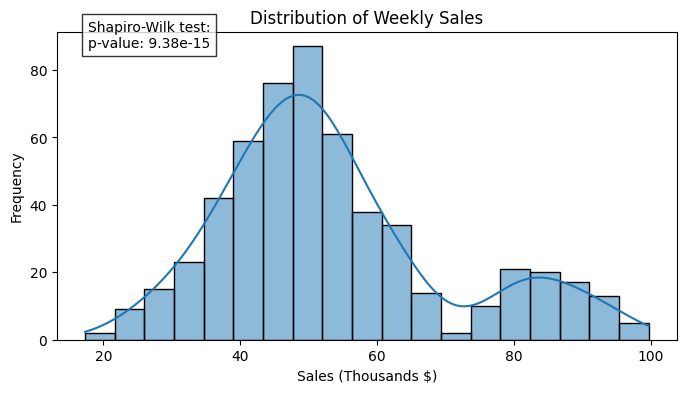

In [85]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="SalesInThousands", kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales (Thousands $)")
plt.ylabel("Frequency") 

shapiro_stat, shapiro_p = stats.shapiro(df["SalesInThousands"])
plt.text(0.05, 0.95, f'Shapiro-Wilk test:\np-value: {shapiro_p:.2e}',
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

#### 5.3 Levene's Test

In [89]:
_, p = stats.levene(*[df[df['Promotion'] == p]['SalesInThousands'] for p in [1, 2, 3]])
print(f"Levene's test p-value: {p:.4f}")

Levene's test p-value: 0.2818


#### 5.4 ANOVA Test

In [86]:
anova_stat, anova_p = f_oneway(
    df[df["Promotion"] == 1]["SalesInThousands"],
    df[df["Promotion"] == 2]["SalesInThousands"],
    df[df["Promotion"] == 3]["SalesInThousands"],
)
print(f"ANOVA test statistic: {anova_stat:.2f}, p-value: {anova_p:.2e}")

ANOVA test statistic: 21.95, p-value: 6.77e-10


The ANOVA test results indicate that there are statistically significant differences in the average weekly sales among the three promotions. The very small p-value suggests that these differences are unlikely to be due to random chance.

#### 5.5 Estimated Treatment Effect

Mean Sales by Promotion: {1: '58.10', 2: '47.33', 3: '55.36'}

Estimated Treatment Effect (compared to Promotion 1): {1: '0.00', 2: '-10.77', 3: '-2.73'}


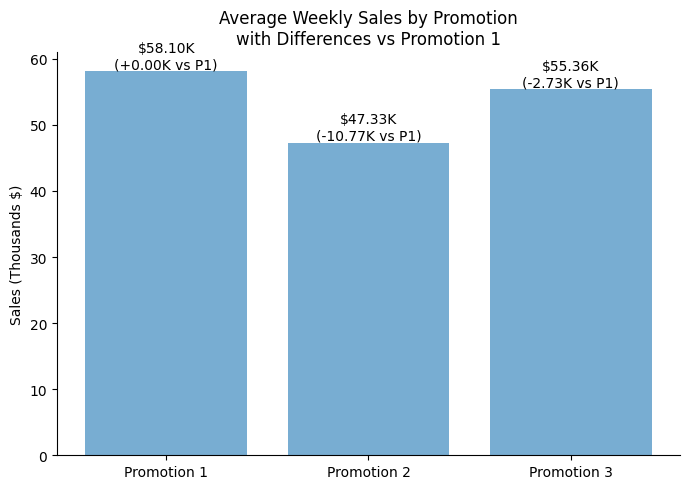

In [87]:
mean_sales = df.groupby("Promotion")["SalesInThousands"].mean()
print("Mean Sales by Promotion:", {k: f"{v:.2f}" for k, v in mean_sales.to_dict().items()})
treatment_effect = mean_sales - mean_sales[1]
print("\nEstimated Treatment Effect (compared to Promotion 1):", {k: f"{v:.2f}" for k, v in treatment_effect.to_dict().items()})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(3), mean_sales, alpha=0.6)
ax.set(xticks=range(3), xticklabels=[f"Promotion {i}" for i in [1, 2, 3]], 
       title="Average Weekly Sales by Promotion\nwith Differences vs Promotion 1",
       ylabel="Sales (Thousands $)")

for i, bar in enumerate(bars):
    ax.text(i, bar.get_height(), f'${bar.get_height():.2f}K\n({treatment_effect[i+1]:+.2f}K vs P1)',
            ha='center', va='bottom')

ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()
plt.show()

The treatment effect shows how each promotion performed compared to Promotion 1:
- Promotion 1: 0.00 (this is the baseline)
- Promotion 2: -$10,770 (performs $10,770 worse than Promotion 1)
- Promotion 3: -$2,730 (performs $2,730 worse than Promotion 1)

The negative numbers indicate how much less in weekly sales each promotion generated compared to Promotion 1. This clearly shows that
Promotion 1 was the most effective. 

#### 5.6 Confidence Intervals (analytical and bootstrap methods)


Promotion 1: Mean=58.10
Analytical CI: (55.63, 60.57)
Bootstrap CI: (55.52, 60.60)

Promotion 2: Mean=47.33
Analytical CI: (45.17, 49.49)
Bootstrap CI: (45.18, 49.46)

Promotion 3: Mean=55.36
Analytical CI: (52.97, 57.76)
Bootstrap CI: (53.05, 57.84)


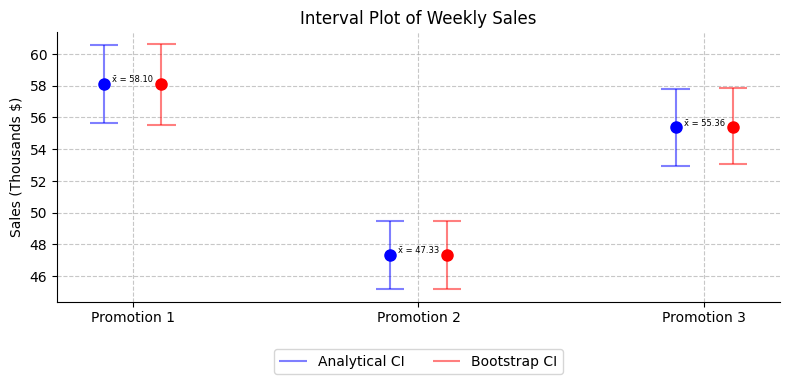

In [88]:
def ci_calc(data, method='analytical'):
    mean = np.mean(data)
    return (mean - norm.ppf(0.975) * np.std(data, ddof=1) / np.sqrt(len(data)), 
            mean + norm.ppf(0.975) * np.std(data, ddof=1) / np.sqrt(len(data))) if method == 'analytical' else \
           np.percentile([np.mean(np.random.choice(data, len(data), True)) for _ in range(1000)], [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.grid(True, linestyle="--", alpha=0.7)
ax.spines[["right", "top"]].set_visible(False)

for i, p in enumerate([1, 2, 3]):
    data = df[df["Promotion"] == p]["SalesInThousands"]
    mean = np.mean(data)
    print(f"\nPromotion {p}: Mean={mean:.2f}")
    for j, (method, color) in enumerate([('analytical', 'blue'), ('bootstrap', 'red')]):
        ci = ci_calc(data, method)
        print(f"{method.title()} CI: ({ci[0]:.2f}, {ci[1]:.2f})")
        ax.vlines(i + j*0.2, *ci, color=color, alpha=0.5, label=f"{method.title()} CI" if i==0 else "")
        ax.hlines(ci, i + j*0.2 - 0.05, i + j*0.2 + 0.05, color=color, alpha=0.5)
        ax.plot(i + j*0.2, mean, f"{color[0]}o", markersize=8)
    ax.text(i + 0.1, mean, f"x̄ = {mean:.2f}", ha="center", va="bottom", fontsize=6)

ax.set(title="Interval Plot of Weekly Sales", ylabel="Sales (Thousands $)",
       xticks=np.arange(3) + 0.1, xticklabels=[f"Promotion {i}" for i in [1, 2, 3]])
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=2)
plt.tight_layout()
plt.show()


Both methods gave very similar results, which suggests the data is well-behaved and the analytical assumptions are reasonable. The confidence intervals show us where we can expect the true average sales to be for each promotion, with 95% certainty:

- Promotion 1: Between $55,630-$60,570 (best performer)
- Promotion 2: Between $45,170-$49,490 (worst performer)
- Promotion 3: Between $52,970-$57,760 (middle performer)


### 6. DECISION 

**Hypothesis**

Based on our analysis, we reject the null hypothesis that all promotions generate equal weekly sales. The data provides strong evidence that at least one promotion generates significantly different sales, supporting our alternative hypothesis (H₁).Specifically, our analysis reveals Promotion 1 generates significantly higher weekly sales compared to the other promotions. 

**Recommendation**

Based on these results, I strongly recommend implementing Promotion 1 as the marketing strategy for the new menu item. 